# Triage Prediction Pipeline - OOP Implementation

This notebook implements a complete triage prediction pipeline using Object-Oriented Programming principles.

## 1. Load Data

In [35]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")

# Import our own modules
from modules.data_loader import load_data
from modules.preprocessing import NumericalPreprocessor, CategoricalPreprocessor, TextPreprocessor, FeatureBuilder
from modules.visualization import DataAnalysis, TrainDataVisualizer, PatientHistoryDataVisualizer, TextDataVisualizer
from modules.models import ModelTrainer
from modules.evaluation import ModelEvaluator, ModelExporter
from modules.config import SEED, TARGET, TEST_SIZE
from sklearn.model_selection import train_test_split

In [36]:
# Load data using OOP DataLoader
chief_complaint_data, patient_history_data, train_data, test_data, sample_submission_data = load_data()
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (80000, 66)
Test data shape: (20000, 63)


In [37]:
# Reload modules to get latest changes
import importlib
import modules.visualization
importlib.reload(modules.visualization)
from modules.visualization import DataAnalysis, TrainDataVisualizer, PatientHistoryDataVisualizer,TextDataVisualizer

# Reinitialize objects with reloaded modules
data_analysis = DataAnalysis(train_data)

In [38]:
# Reload preprocessing module
import importlib
import modules.preprocessing
importlib.reload(modules.preprocessing)
from modules.preprocessing import NumericalPreprocessor, CategoricalPreprocessor, TextPreprocessor, FeatureBuilder

In [39]:
# Set environment seed for reproducible results
def seeder(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
seeder(SEED)

## 2. Data Analysis and Visualization

In [40]:
# Initialize DataAnalysis and DataVisualizer
data_analysis = DataAnalysis(train_data)
data_visualizer = TrainDataVisualizer()

In [41]:
# Analyze missing values
missing_analysis = data_analysis.analyze_missing_values()
print("Missing values analysis:")
print(missing_analysis)

Missing values analysis:
                                        column  missing_count  \
systolic_bp                        systolic_bp           4146   
diastolic_bp                      diastolic_bp           4146   
mean_arterial_pressure  mean_arterial_pressure           4146   
pulse_pressure                  pulse_pressure           4146   
shock_index                        shock_index           4146   
respiratory_rate              respiratory_rate           3067   
temperature_c                    temperature_c            574   

                        missing_percentage  
systolic_bp                           5.18  
diastolic_bp                          5.18  
mean_arterial_pressure                5.18  
pulse_pressure                        5.18  
shock_index                           5.18  
respiratory_rate                      3.83  
temperature_c                         0.72  


In [42]:
# Plot missing values heatmap
data_visualizer.plot(plot_type="missing_heatmap", data=train_data, missing_analysis=missing_analysis)

TypeError: TrainDataVisualizer.plot() got an unexpected keyword argument 'missing_analysis'

Insight: Some of them are missing in groups. For example, systeolic_bp, diastolic_bp, mean_arterial_pressure, pulse_pressure,shock_index. This means that when the Blood Pressure is missing, all related BP info is also go missing.
This suggests imputation strategies should consider these relationships.

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\target_distribution.png


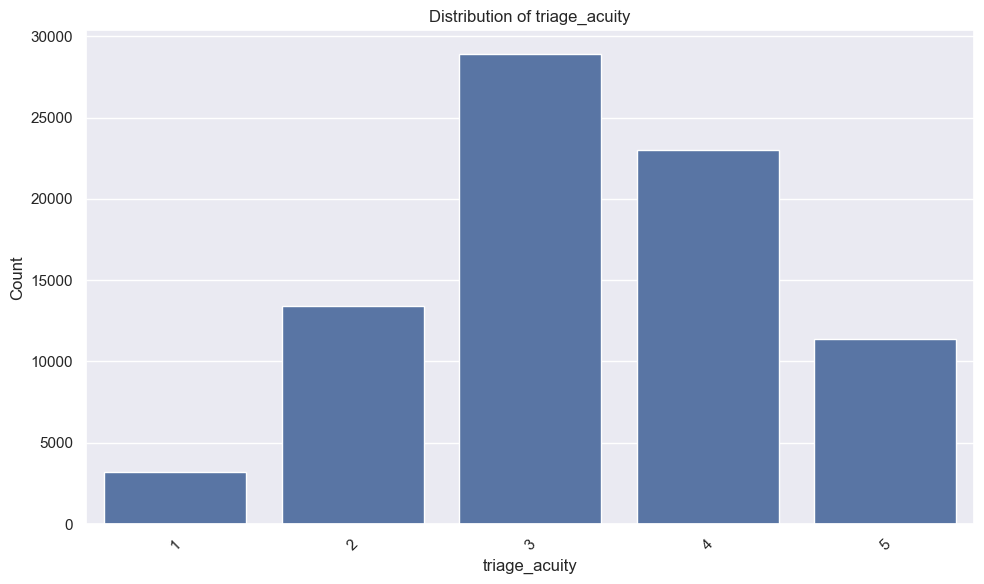

In [ ]:
# Plot target distribution
data_visualizer.plot(plot_type="target_distribution", data=train_data, target_col=TARGET)

**Insight:** The target classes show imbalance with higher representation of less urgent cases. We should use SMOTE for oversampling to balance the classes during training.

In [ ]:
# Analyze correlations
correlation_matrix = data_analysis.analyze_correlations(target_col=TARGET)
print("\nCorrelations with target:")
print(correlation_matrix)


Correlations with target:
                                triage_acuity
news2_score                         -0.814804
ed_los_hours                        -0.756714
respiratory_rate                    -0.652945
temperature_c                       -0.649193
shock_index                         -0.631830
pain_score                          -0.618834
heart_rate                          -0.567962
num_prior_ed_visits_12m             -0.564138
num_prior_admissions_12m            -0.311197
num_comorbidities                   -0.142150
num_active_medications              -0.094220
hx_hyperthyroidism                  -0.053749
hx_liver_disease                    -0.052915
hx_coagulopathy                     -0.051430
hx_anxiety                          -0.051357
hx_immunosuppressed                 -0.050834
hx_asthma                           -0.050180
hx_diabetes_type1                   -0.049388
hx_hiv                              -0.048820
hx_epilepsy                         -0.048331
hx_mali

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\correlation_heatmap.png


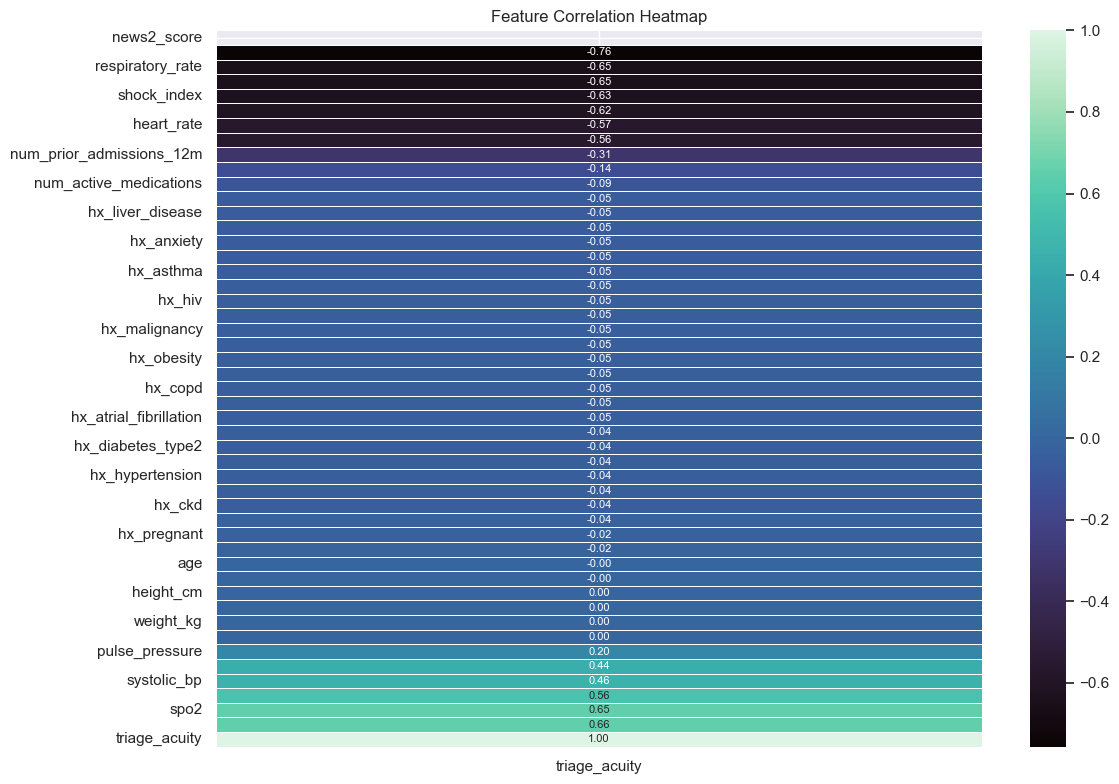

In [ ]:
# Plot correlation heatmap
data_visualizer.plot(plot_type="correlation_heatmap", correlation_matrix=correlation_matrix)

**Insight:** Features like 'news2_score' and 'shock_index' show strong correlations with acuity level, validating their importance in triage decisions.

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\numerical_distributions.png


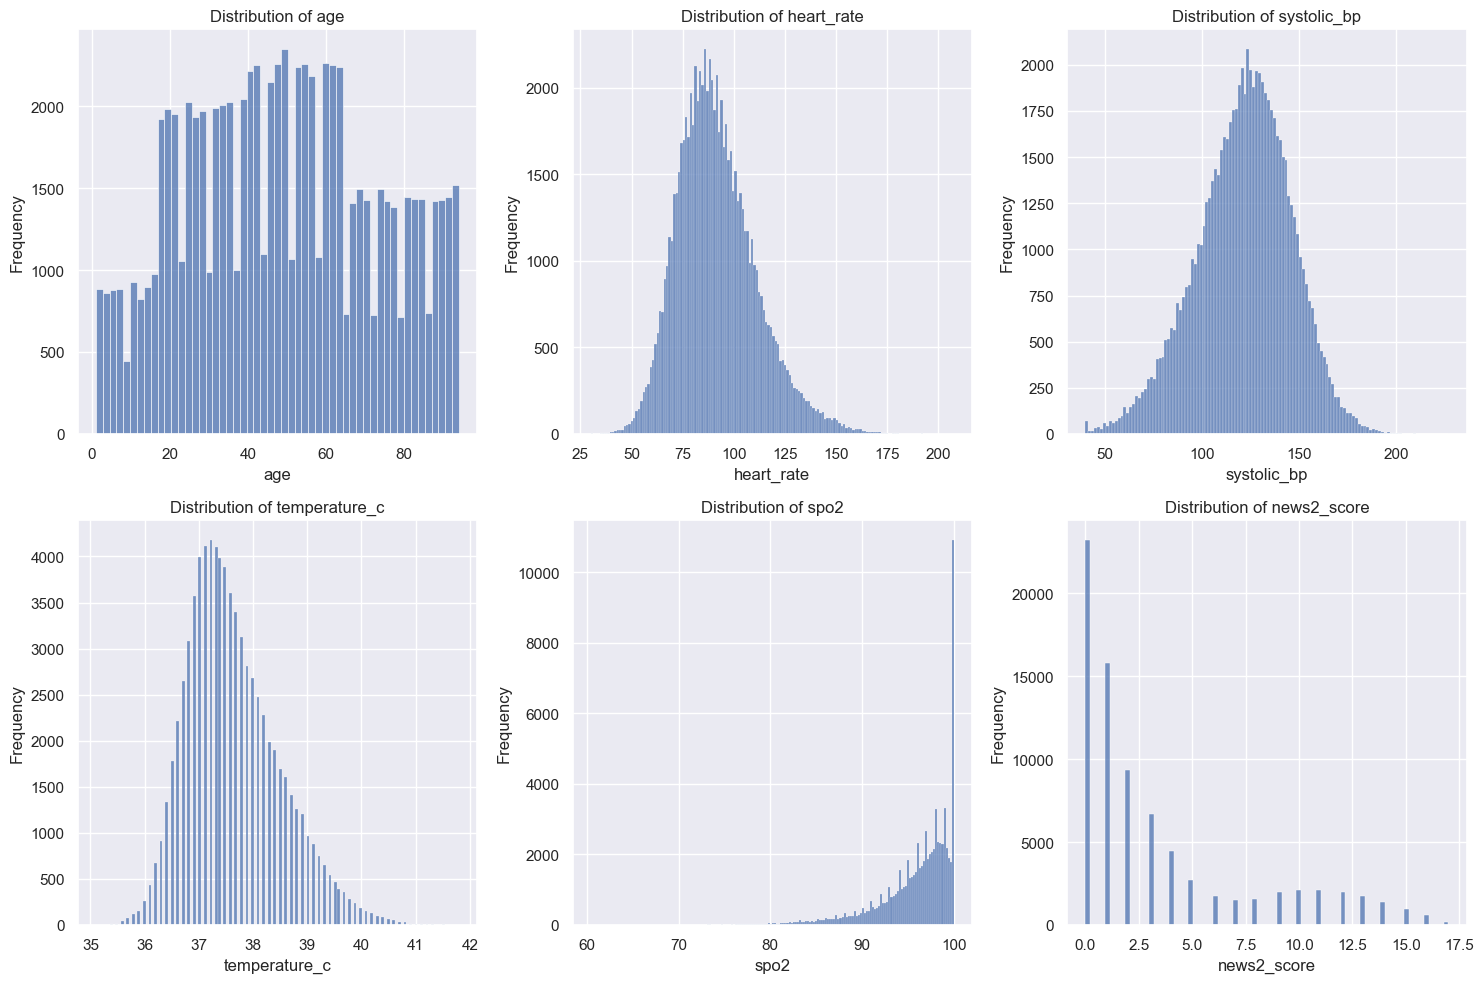

In [ ]:
# Plot numerical distributions
key_numerical_cols = ['age', 'heart_rate', 'systolic_bp', 'temperature_c', 'spo2', 'news2_score']
data_visualizer.plot(plot_type="numerical_distributions", data=train_data, num_cols=key_numerical_cols)

**Insight:** Numerical features show varying distributions. Features like 'news2_score' have right-skewed distributions typical of medical scoring systems, justifying the use of StandardScaler for normalization.

## 2.1 Patient History Data Analysis and Visualization

In [ ]:
# Initialize PatientHistoryDataVisualizer
patient_history_visualizer = PatientHistoryDataVisualizer(patient_history_data)

In [ ]:
# Analyze patient history conditions
condition_counts = patient_history_visualizer.analyze_conditions()

CONDITION ANALYSIS
Most common condition: hx_coronary_artery_disease
Least common condition: hx_pregnant
Top 5 conditions:
hx_coronary_artery_disease    28182
hx_atrial_fibrillation        28149
hx_ckd                        28142
hx_heart_failure              28081
hx_hypertension               28067
dtype: int64


Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\patient_history_condition_counts.png


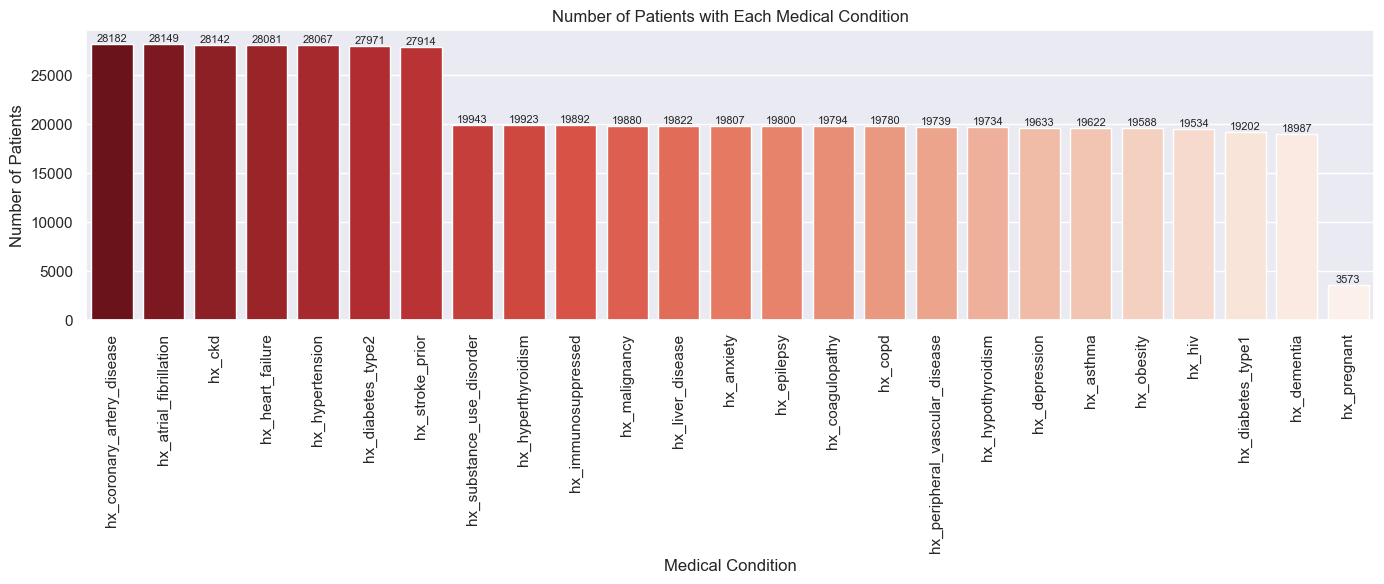

In [ ]:
# Plot condition counts
patient_history_visualizer.plot(plot_type="condition_counts")

**Insight:** Patient history shows varying prevalence of medical conditions. Common conditions like hypertension and diabetes may require special handling in preprocessing, while rare conditions might need grouping or feature engineering to avoid sparsity issues.

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\patient_history_condition_percentages.png


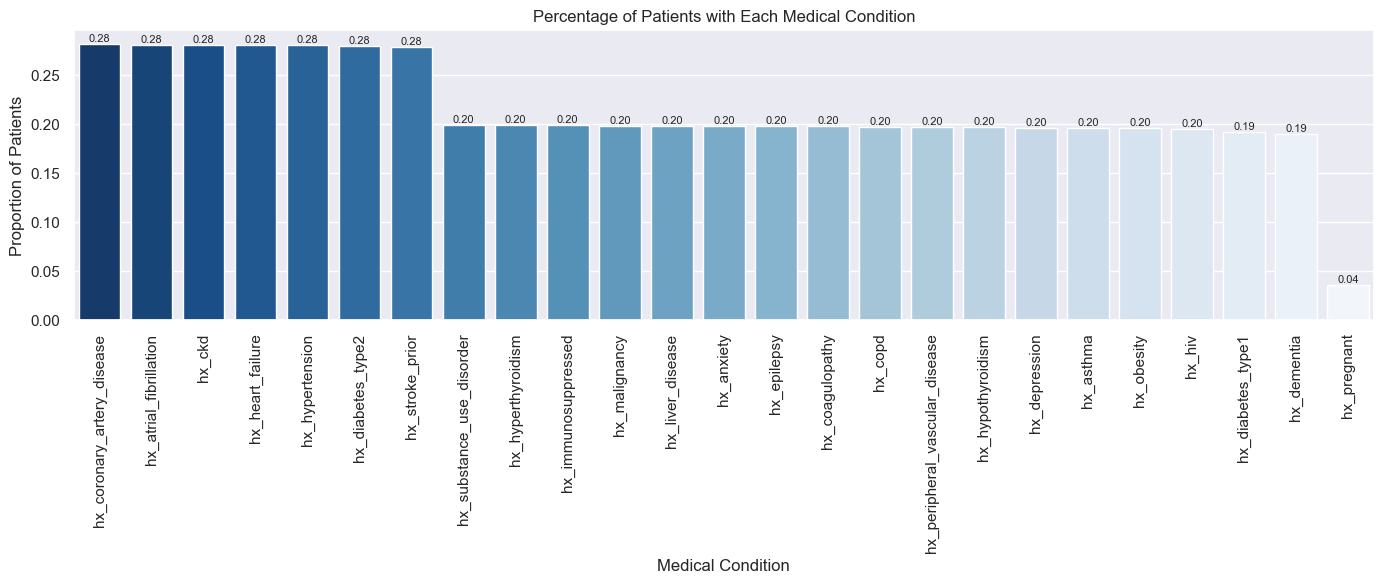

In [ ]:
# Plot condition percentages
patient_history_visualizer.plot(plot_type="condition_percentages")

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\patient_history_condition_correlations.png


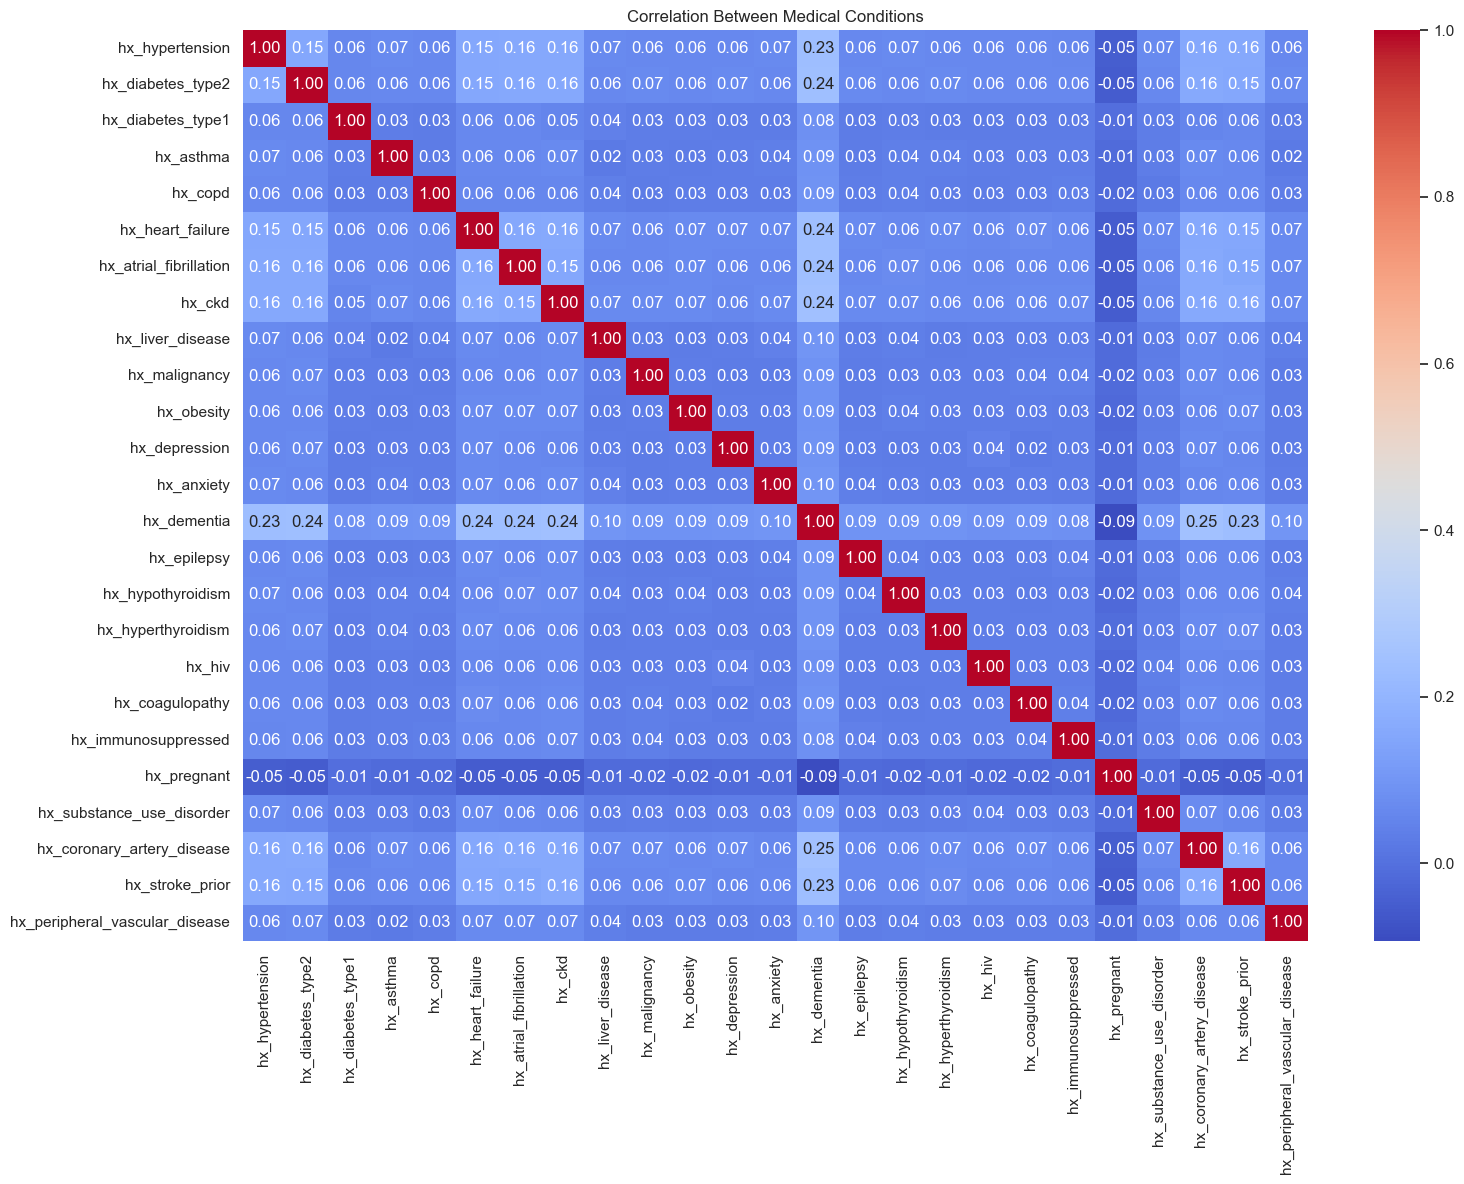

In [ ]:
# Plot condition correlations
patient_history_visualizer.plot(plot_type="condition_correlations")

**Insight:** Some medical conditions show correlations (e.g., cardiovascular conditions). This suggests that dimensionality reduction techniques or feature selection might be beneficial during preprocessing to handle multicollinearity.

## 2.2 Text Data Analysis and Visualization

In [ ]:
# Initialize TextDataVisualizer
text_visualizer = TextDataVisualizer(chief_complaint_data)

In [ ]:
# Analyze text lengths
text_stats = text_visualizer.analyze_text_lengths()

TEXT LENGTH ANALYSIS
mean_length: 39.68
median_length: 39.00
min_length: 7.00
max_length: 77.00
std_length: 9.84


Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\text_length_distribution.png


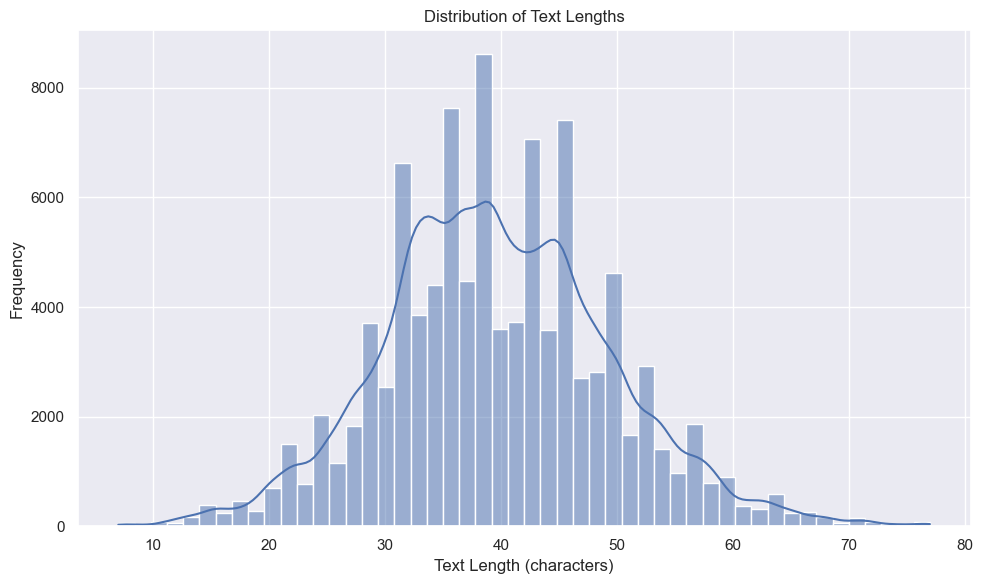

In [ ]:
# Plot text length distribution
text_visualizer.plot(plot_type="text_length_distribution")

**Insight:** Text lengths vary significantly. Very short complaints might need different preprocessing than longer ones. This suggests using adaptive text preprocessing strategies or separate handling for brief vs detailed complaints.

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\word_count_distribution.png


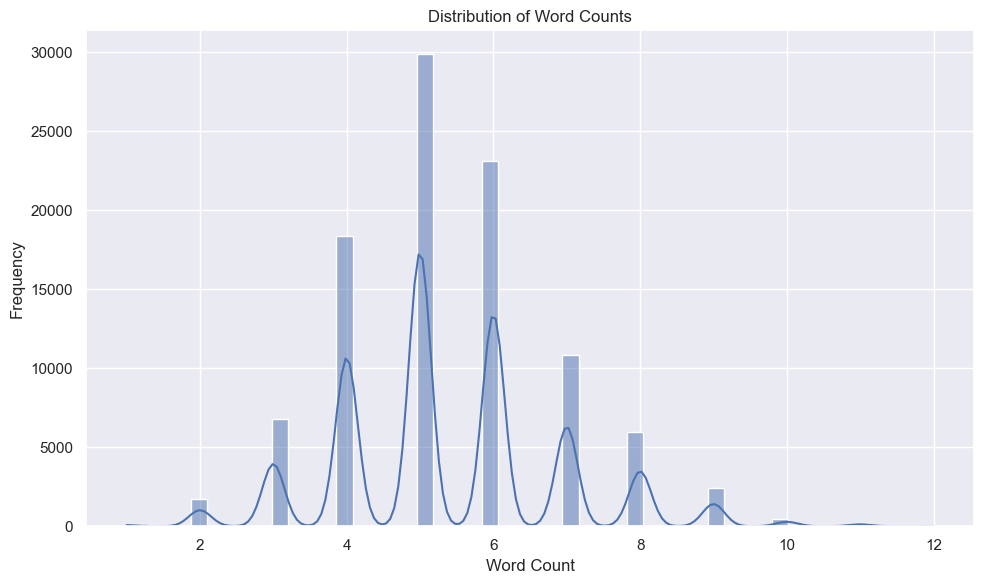

In [ ]:
# Plot word count distribution
text_visualizer.plot(plot_type="word_count_distribution")

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\common_words.png


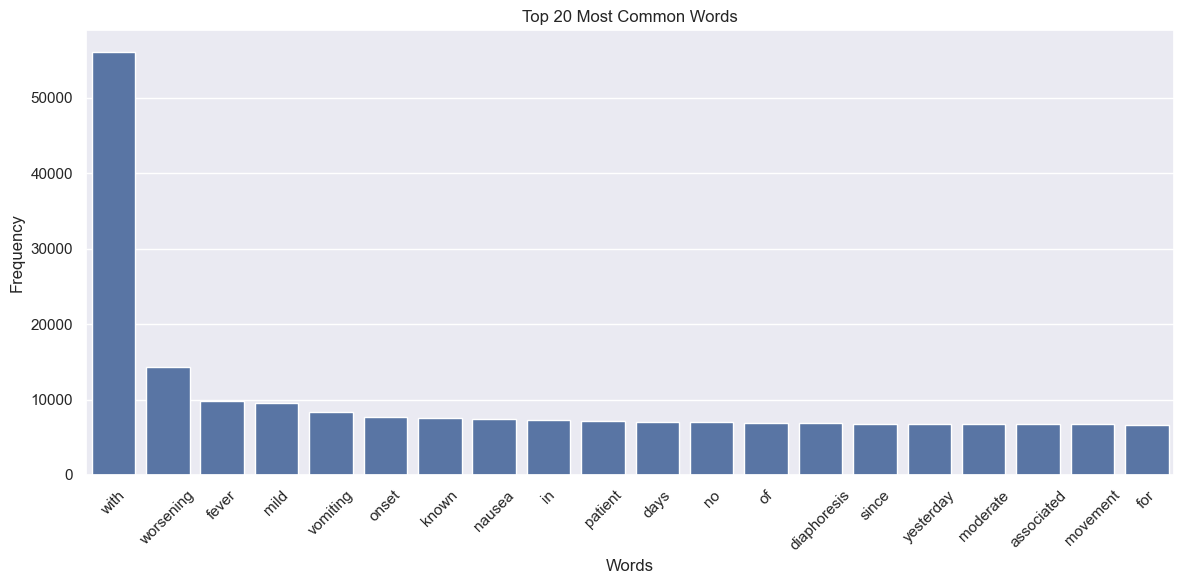

In [ ]:
# Plot common words
text_visualizer.plot(plot_type="common_words")

**Insight:** Common medical terms dominate the vocabulary. Stop word removal and domain-specific preprocessing will be crucial. The presence of medical jargon suggests TF-IDF with custom vocabulary might be more effective than generic text processing.

Saved figure: d:\Desktop\CADT\Year_2\Term2\OOP-Python\Project\modules\..\image\text_length_by_category.png


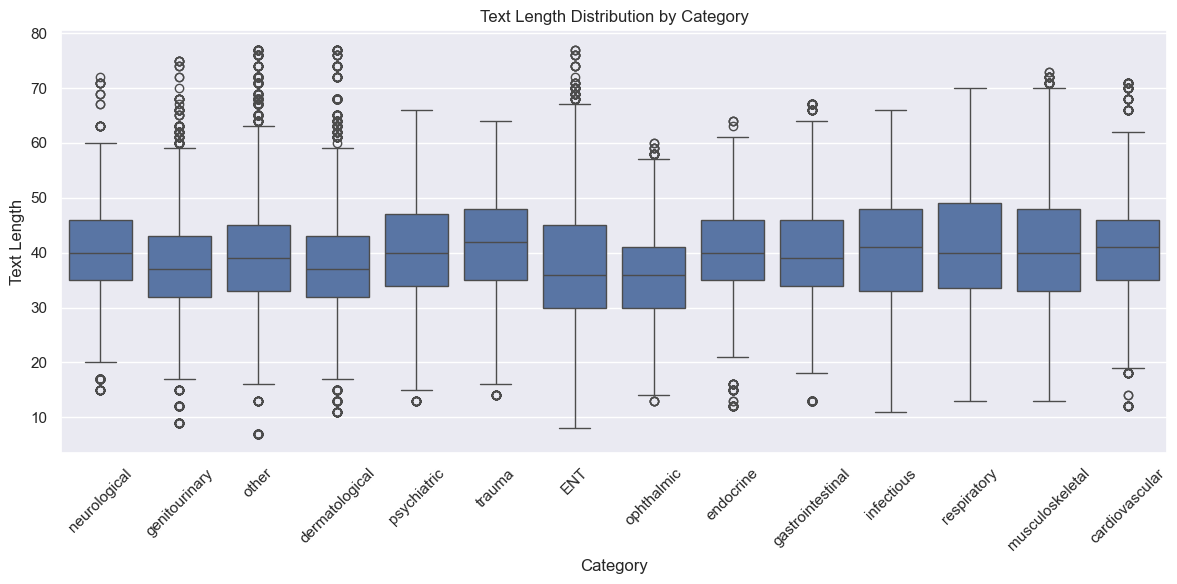

In [ ]:
# Plot text length by category
text_visualizer.plot(plot_type="text_length_by_category")

**Insight:** Different complaint categories have varying text lengths. This indicates that preprocessing should consider complaint type - neurological complaints might need different text processing than dermatological ones.

## 2.3 Combined Data Insights and Preprocessing Strategy

**Combined Insights:**
- **Missing Values:** Grouped missing patterns in vital signs suggest multivariate imputation
- **Class Imbalance:** SMOTE needed for target balancing
- **Feature Correlations:** Strong medical score correlations validate feature importance
- **Patient History:** Condition correlations suggest feature engineering opportunities
- **Text Data:** Variable lengths and medical terminology require specialized preprocessing

**Preprocessing Strategy:**
1. Handle missing values with pattern-aware imputation
2. Scale numerical features with outlier clipping
3. Encode categorical features appropriately
4. Process text with medical-aware TF-IDF
5. Engineer features from patient history correlations
6. Apply SMOTE for class balancing

## 3. Data Preprocessing

In [ ]:
# Initialize preprocessors
numerical_preprocessor = NumericalPreprocessor()
categorical_preprocessor = CategoricalPreprocessor()
text_preprocessor = TextPreprocessor(text_col='chief_complaint_raw')

# Create feature builder with all preprocessors
preprocessors = [numerical_preprocessor, categorical_preprocessor, text_preprocessor]
feature_builder = FeatureBuilder(preprocessors)

CategoricalPreprocessor.__init__ called with max_categories=50, exclude_patterns=None


In [ ]:
# Debug: Check preprocessors
print("Preprocessors list:")
for i, p in enumerate(preprocessors):
    print(f"  {i}: {type(p).__name__}")

Preprocessors list:
  0: NumericalPreprocessor
  1: CategoricalPreprocessor
  2: TextPreprocessor


In [ ]:
# Split train data into train and validation sets
leak_cols = ['ed_los_hours', 'disposition', TARGET]
X = train_data.drop(columns=[c for c in leak_cols if c in train_data.columns])
y = train_data[TARGET] - 1
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
X_test = test_data.drop(columns=[c for c in leak_cols if c in test_data.columns], errors='ignore')

In [ ]:
# Check unique values in y_train
print("Unique values in y_train:", np.unique(y_train))

Unique values in y_train: [0 1 2 3 4]


In [ ]:
# Build features using OOP pipeline
feature_builder.fit(X_train)
X_train_features = feature_builder.transform(X_train)
X_val_features = feature_builder.transform(X_val)
X_test_features = feature_builder.transform(X_test)

FeatureBuilder.fit() called with 3 preprocessors
Fitting preprocessor 0: NumericalPreprocessor
Preprocessor 0 fit completed
Fitting preprocessor 1: CategoricalPreprocessor
CategoricalPreprocessor.fit() START
CategoricalPreprocessor: Found 16 categorical columns: ['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_day', 'arrival_season', 'shift', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system', 'chief_complaint_raw']
  ✗ Excluding column 'patient_id' from one-hot encoding (64000 unique values)
  ✗ Excluding column 'site_id' from one-hot encoding (5 unique values)
  ✗ Excluding column 'triage_nurse_id' from one-hot encoding (50 unique values)
  ✓ Including column 'arrival_mode' (6 unique values)
  ✓ Including column 'arrival_day' (7 unique values)
  ✓ Including column 'arrival_season' (4 unique values)
  ✓ Including column 'shift' (4 unique values)
  ✓ Including column 'age_group' (4

In [ ]:
# Validate feature matrix shapes
print('X_train_features shape:', X_train_features.shape)
print('X_val_features shape:', X_val_features.shape)
print('X_test_features shape:', X_test_features.shape)

X_train_features shape: (64000, 631)
X_val_features shape: (16000, 631)
X_test_features shape: (20000, 631)


In [ ]:
# Test fit method separately
print("Testing fit method...")
feature_builder.fit(X_train)
print("Fit completed successfully")

Testing fit method...
FeatureBuilder.fit() called with 3 preprocessors
Fitting preprocessor 0: NumericalPreprocessor
Preprocessor 0 fit completed
Fitting preprocessor 1: CategoricalPreprocessor
CategoricalPreprocessor.fit() START
CategoricalPreprocessor: Found 17 categorical columns: ['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_day', 'arrival_season', 'shift', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system', 'disposition', 'chief_complaint_raw']
  ✗ Excluding column 'patient_id' from one-hot encoding (64000 unique values)
  ✗ Excluding column 'site_id' from one-hot encoding (5 unique values)
  ✗ Excluding column 'triage_nurse_id' from one-hot encoding (50 unique values)
  ✓ Including column 'arrival_mode' (6 unique values)
  ✓ Including column 'arrival_day' (7 unique values)
  ✓ Including column 'arrival_season' (4 unique values)
  ✓ Including column 'shift' (4 unique values

In [ ]:
# Check categorical preprocessor state after fit
print(f"Categorical preprocessor _cat_cols: {categorical_preprocessor._cat_cols}")
print(f"Categorical preprocessor max_categories: {categorical_preprocessor.max_categories}")
print(f"Categorical preprocessor exclude_patterns: {categorical_preprocessor.exclude_patterns}")

Categorical preprocessor _cat_cols: None


AttributeError: 'CategoricalPreprocessor' object has no attribute 'max_categories'

In [ ]:
# Test if prints work
print("Testing print functionality")
print("This should show up")

Testing print functionality
This should show up


In [ ]:
# Quick leak detection check using freshly loaded data
from modules.data_loader import load_data
_,_,train_data,_,_ = load_data()
print('train shape', train_data.shape)
print('target distribution', train_data['acuity_level'].value_counts(normalize=True).to_dict())
leak_cols = [c for c in train_data.columns if any(x in c.lower() for x in ['los','departure','admit'])]
print('leak_cols', leak_cols)

corr = train_data.select_dtypes(include='number').corr()['acuity_level'].abs().sort_values(ascending=False)
print(corr.head(20))

train shape (80000, 66)


KeyError: 'acuity_level'

In [ ]:
from modules.config import TARGET
print('TARGET', TARGET)
print('columns in train_data:', train_data.columns.tolist())

TARGET triage_acuity
columns in train_data: ['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score', 'disposition', 'ed_los_hours', 'triage_acuity', 'chief_complaint_raw', 'hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1', 'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation', 'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 'hx_obesity', 'hx_depression', 'hx_anxiety', 'hx_dementia', 'hx_epilepsy', 'hx_hypothyroidism', 'hx_h

In [ ]:
# Check unique values in y_train
print("Unique values in y_train:", np.unique(y_train))

Unique values in y_train: [0 1 2 3 4]


## 4. Machine Learning

In [ ]:
# Analyze categorical columns to identify high-cardinality features
print("Analyzing categorical columns...")
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
print(f"Number of categorical columns: {len(categorical_cols)}")

for col in categorical_cols:
    unique_count = X_train[col].nunique()
    print(f"{col}: {unique_count} unique values")
    if unique_count > 50:  # Flag high-cardinality columns
        print(f"  ⚠️  HIGH CARDINALITY: {col} has {unique_count} unique values")
        # Show top 10 most frequent values
        top_values = X_train[col].value_counts().head(10)
        print(f"  Top 10 values: {top_values.to_dict()}")

Analyzing categorical columns...
Number of categorical columns: 17
patient_id: 64000 unique values
  ⚠️  HIGH CARDINALITY: patient_id has 64000 unique values
  Top 10 values: {'TG-MVVZ0YV3P': 1, 'TG-QY12ID7X6': 1, 'TG-YNE73UQLW': 1, 'TG-H9GB3RJMC': 1, 'TG-M8JW0HAV8': 1, 'TG-JW4PG912P': 1, 'TG-3SCI09BD2': 1, 'TG-23E6WBNW6': 1, 'TG-9HK9XP124': 1, 'TG-KF6YWS2UA': 1}
site_id: 5 unique values
triage_nurse_id: 50 unique values
arrival_mode: 6 unique values
arrival_day: 7 unique values
arrival_season: 4 unique values
shift: 4 unique values
age_group: 4 unique values
sex: 3 unique values
language: 8 unique values
insurance_type: 5 unique values
transport_origin: 7 unique values
pain_location: 9 unique values
mental_status_triage: 5 unique values
chief_complaint_system: 14 unique values
disposition: 7 unique values
chief_complaint_raw: 4910 unique values
  ⚠️  HIGH CARDINALITY: chief_complaint_raw has 4910 unique values
  Top 10 values: {'STI with systemic features in known patient': 37, 'new-o

In [ ]:
# Initialize and train models using OOP ModelTrainer
model_trainer = ModelTrainer()
trained_models = model_trainer.train_models(X_train_features, y_train)
print("Trained models:", list(trained_models.keys()))

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Trained models: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 5. Model Evaluation and Comparison

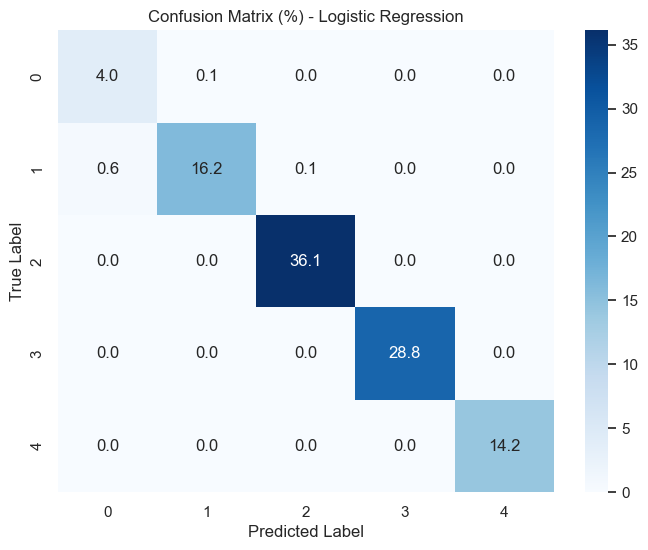

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.87      0.98      0.93       644
           1       0.99      0.96      0.98      2688
           2       1.00      1.00      1.00      5784
           3       1.00      1.00      1.00      4604
           4       1.00      1.00      1.00      2280

    accuracy                           0.99     16000
   macro avg       0.97      0.99      0.98     16000
weighted avg       0.99      0.99      0.99     16000



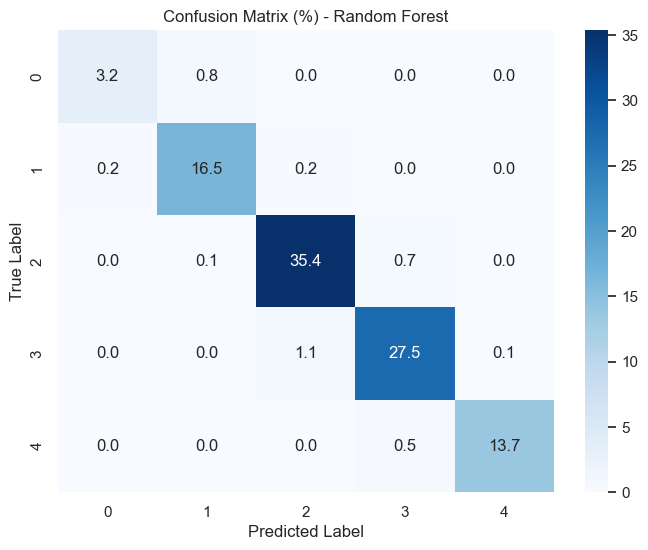

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       644
           1       0.95      0.98      0.96      2688
           2       0.96      0.98      0.97      5784
           3       0.96      0.96      0.96      4604
           4       0.99      0.96      0.98      2280

    accuracy                           0.96     16000
   macro avg       0.96      0.94      0.95     16000
weighted avg       0.96      0.96      0.96     16000



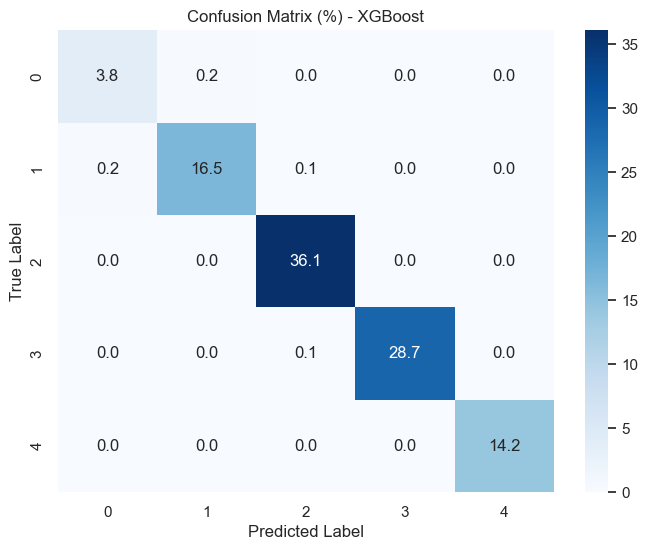

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       644
           1       0.99      0.98      0.98      2688
           2       1.00      1.00      1.00      5784
           3       1.00      1.00      1.00      4604
           4       1.00      1.00      1.00      2280

    accuracy                           0.99     16000
   macro avg       0.99      0.99      0.99     16000
weighted avg       0.99      0.99      0.99     16000


Model Evaluation Results:
                 Model  Accuracy  Precision    Recall  F1-Score ROC-AUC
0  Logistic Regression  0.992563   0.993185  0.992563  0.992692    None
1        Random Forest  0.962938   0.963035  0.962938  0.962632    None
2              XGBoost  0.993750   0.993745  0.993750  0.993746    None


In [ ]:
# Evaluate models using OOP ModelEvaluator
model_evaluator = ModelEvaluator()
evaluation_results = model_evaluator.evaluate_models(trained_models, X_val_features, y_val)
print("\nModel Evaluation Results:")
print(evaluation_results)

## 6. Export Best Model

In [ ]:
# Export best model using OOP ModelExporter
model_exporter = ModelExporter()
exported_path = model_exporter.export_best_model(trained_models, evaluation_results, metric='F1-Score')
print(f"\nBest model exported to: {exported_path}")

Exported best model 'XGBoost' (Score: 0.9933) to output\best_model_ranked.pkl

Best model exported to: output\best_model_ranked.pkl
